<a href="https://colab.research.google.com/github/psaw/hse-ai24-dl/blob/stepik/stepik/9.3%20-%20RNN_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация последовательностей (текстов) при помощи RNN

Сегодня речь пойдёт о задаче классификации текстовых последовательностей. Для этого будем пользоваться датасетом IMDB (датасет содержит отзывы на фильмы, и необходимо определить их тональность - позитивные или негативные) и библиотекой `torchtext`. В торчтексте реализовано огромное число методов для обработки текстов, ими мы и воспользуемся.

__ВАЖНО__. Торчтекст не рекомендуется использовать для обучения на больших данных (от миллиона примеров и больше) из-за маленькой скорости работы. В таких случаях рекомендуется имплементировать свои датасеты. В наших примерах таких объёмов данных не будет.

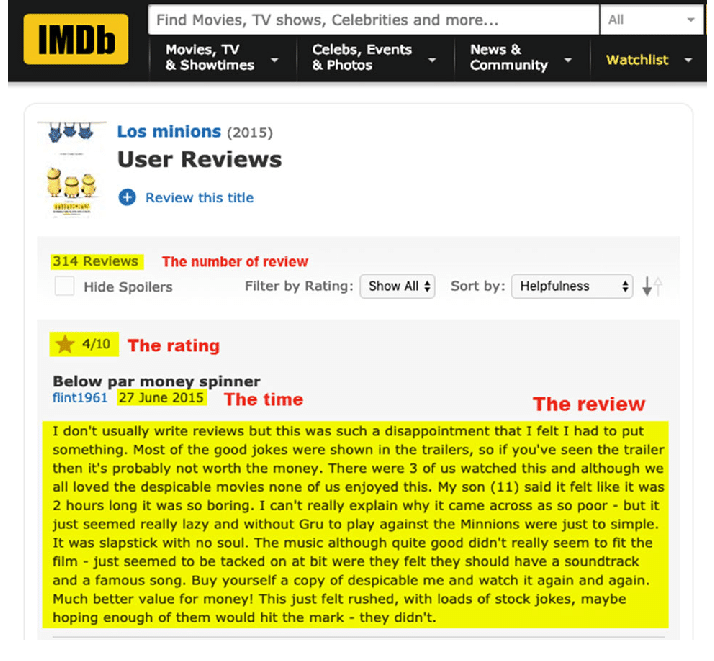

## Начнём с модели.

Да, не самая привычная последовательность действий, но давайте сначала сделаем кое-что, с чем мы уже знакомы -- имплементируем модель.

На вход она будет принимать батч последовательностей токенов, разумеется разной длины в разных батчах, а на выходе выдавать батч вероятностей классов, прямо как в классификации картинок.

Каждый токен пройдёт вначале через эмбеддинг, а затем последовательность эмбеддингов пройдёт через LSTM. Самое последнее скрытое состояние будем считать векторным представлением для последовательности, поверх неё мы навесим линейный слой.

## Задание 1

Допишите конструктор класса. Инициализируйте слои:
* Embedding-слой, принимающий на вход num_embedding и выдающий векторы размера embedding_size

* LSTM-слой, принимающий на вход вектор размера embedding_size, имеющий скрытое состояние размера hidden_size. Также задайте batch_first=True

* Линейный слой, принимающий на вход вектор размера hidden_size и выдающий одно число.

In [ ]:
import pandas as pd
import torch
from torch import nn


class TextClassifier(nn.Module):
    def __init__(
        self,
        num_embeddings=25002,
        embedding_size=300,
        hidden_size=200,
        num_classes=2,
        num_layers=1,
    ):
        super(TextClassifier, self).__init__()
        self.embedding = ...
        self.lstm = ...
        self.linear = ...

    def forward(self, x):
        embedded = self.embedding(x)
        _, (last_hidden, last_c) = self.lstm(embedded)
        return self.linear(last_hidden[0]).squeeze()


model = TextClassifier()

Запустите код ниже. Если он отработал без ошибок - все написано верно!

In [ ]:
model(torch.tensor([[1, 2, 3, 4], [1, 2, 3, 4]]))

## Скачаем и проинициализируем датасет

Дальше перейдём к торчтексту. Он почти как знакомый нам `torchvision` имеет внутри себя коллекцию датасетов для разных задач NLP в том числе и отзывы на IMDB. Инициализация датасета порой занимает время, не следует волноваться и судорожно перезапускать ядро.

In [ ]:
!pip show torchtext

In [ ]:
!pip install torchtext==0.6.0

In [ ]:
import torchtext
from torchtext import data
from torchtext.datasets import IMDB

In [ ]:
# spacy -- вспомогательная библоитека для токенизации текста, скачаем токенайзер для английского языка
! pip install spacy
! python -m spacy download en_core_web_sm

В `torchtext` существует такая сущность, как `Field`. Это просто класс, в котором содержится описание колонок нашего датасета. В нашем случае всё довольно просто. Есть две колонки --- это текст и оценка, назовём их `text_field` и `label_field` соответственно. Токенизовать будем при помощи установленной только что библиотеки `spacy`, лейблы приведём к типу `float`.

Преимущества токенизатора SpaCy:

* SpaCy использует продвинутые правила токенизации, учитывая контекст и особенности языка. Это позволяет ему более точно разбивать текст на токены, учитывая сложные случаи, такие как аббревиатуры, дефисы, сокращения и др.

* Стандартные токенизаторы могут предоставлять базовую функциональность, но они могут не учитывать сложные языковые конструкции и требовать дополнительной настройки.

In [ ]:
from torchtext.data import Field, LabelField

In [ ]:
text_field = Field(
    tokenize="spacy",
    batch_first=True,
    include_lengths=False,
    tokenizer_language="en_core_web_sm",
)

label_field = LabelField(dtype=torch.float32, batch_first=True)

Создадим два сплита нашего датасета. Они задаются при помощи метода splits.

In [ ]:
data_train, data_test = IMDB.splits(text_field, label_field)

downloading aclImdb_v1.tar.gz


aclImdb_v1.tar.gz: 100%|██████████| 84.1M/84.1M [00:14<00:00, 6.00MB/s]


## Задание 2

Посмотрите на первый (с индексом 0) отзыв в data_train. Какой он по тональности?

Подсказка: вам поможет `vars` — это встроенная функция Python, которая возвращает __dict__ атрибут объекта, содержащий его внутренние атрибуты. По сути, vars используется для получения всех свойств объекта в виде словаря.



In [ ]:
# Ваш код здесь

Создадим также словари, соответствующие нашему тексту. Выкинем все слова (токены), которые встречаются редко. Оставим только 25 тысяч самых частых слов.

Также согласуем номера токенов в словаре с эмбеддингами glove. При желании можно согласовать и с word2vec'ом, но имейте ввиду, что glove это их аналог. Об инициализации эмбеддингов мы обязательно поговорим чуть позже.

In [ ]:
vocab_size = 25000

# build_vocab -- создать словарь по данному полю в датасете
text_field.build_vocab(
    data_train,
    max_size=vocab_size,
    vectors="glove.6B.100d",
)

label_field.build_vocab(data_train)

for item in data_train:
    print(item.text)
    break

## Задание 3

Выведите 10 самых часто встречающихся токенов в словаре.
Какой токен третий по частоте встречаемости?

In [ ]:
# ваш код здесь

Сделаем аналог даталоадера.

In [ ]:
train_dataloader, test_dataloader = data.BucketIterator.splits(
    (data_train, data_test), batch_size=32, device="cuda:0"
)

## Задание 4

Возьмите любой батч из train_dataloader. Чему равна самая первая размерность тензора, описывающего поле `text` в батче?

In [ ]:
# ваш код здесь

Длина текста около 1000 символов это очень много для нашей маленькой модельки. Будем обрезать их на 256 токенах в нашем трейн лупе.

## Задание 5

#### Train loop

Перейдём к самому интересному и построим train loop к нашей модели. Но скажем сразу, он мало чем будет отличаться от классификации картинок.

Допишите цикл обучения.

In [ ]:
def train_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    return_losses=False,
    device="cuda:0",
):
    model = model.to(device).train()
    total_loss = 0
    num_batches = 0
    all_losses = []
    total_predictions = np.array([])  # .reshape((0, ))
    total_labels = np.array([])  # .reshape((0, ))

    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for item in data_loader:
            reviews = item.text
            labels = item.label

            # Move Batch to GPU
            reviews = reviews.to(device)
            labels = labels.to(device)
            predicted = ... # сделайте прогнозы при помощи модели
            loss = ... # вычислите loss

            # Update weights
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Update descirption for tqdm
            accuracy = ... # вычислите accuracy
            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            total_predictions = np.append(
                total_predictions, (predicted > 0.5).int().cpu().detach().numpy()
            )
            total_labels = np.append(total_labels, labels.cpu().detach().numpy())
            num_batches += 1
            all_losses.append(loss.detach().item())

    metrics = {"loss": total_loss / num_batches}
    metrics.update({"accuracy": (total_predictions == total_labels).mean()})
    if return_losses:
        return metrics, all_losses
    else:
        return metrics


def validate(model, data_loader, criterion, device="cuda:0"):

    model = model.eval()
    total_loss = 0
    num_batches = 0
    total_predictions = np.array([])
    total_labels = np.array([])

    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for reviews, labels in data_loader:
            reviews = reviews.to(device)
            labels = labels.to(device)
            predicted = model(reviews)

            loss = criterion(predicted, labels)
            accuracy = (predicted.argmax(1) == labels).float().mean()

            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            total_predictions = np.append(
                total_predictions, predicted.argmax(1).cpu().detach().numpy()
            )
            total_labels = np.append(total_labels, labels.cpu().detach().numpy())
            num_batches += 1

    metrics = {"loss": total_loss / num_batches}
    metrics.update({"accuracy": (total_predictions == total_labels).mean()})
    return metrics

## Задание 6

Запустите обучение модели. Чему равен loss на третьей по счету эпохе?

Оставьте в значении loss два знака после запятой, остальные отбросьте.

In [ ]:
import sys

import numpy as np
from tqdm.notebook import tqdm

device = "cuda:0"
model = TextClassifier()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for i in range(10):
    train_epoch(
        model, train_dataloader, criterion=criterion, optimizer=optimizer, device=device
    )

Кажется, обучается так себе. Давайте это исправлять!

Попробуем сделать следующее:

* сделаем модель двунаправленной

* добавим DropOut

* инициализируем эмбеддинги GloVe векторами

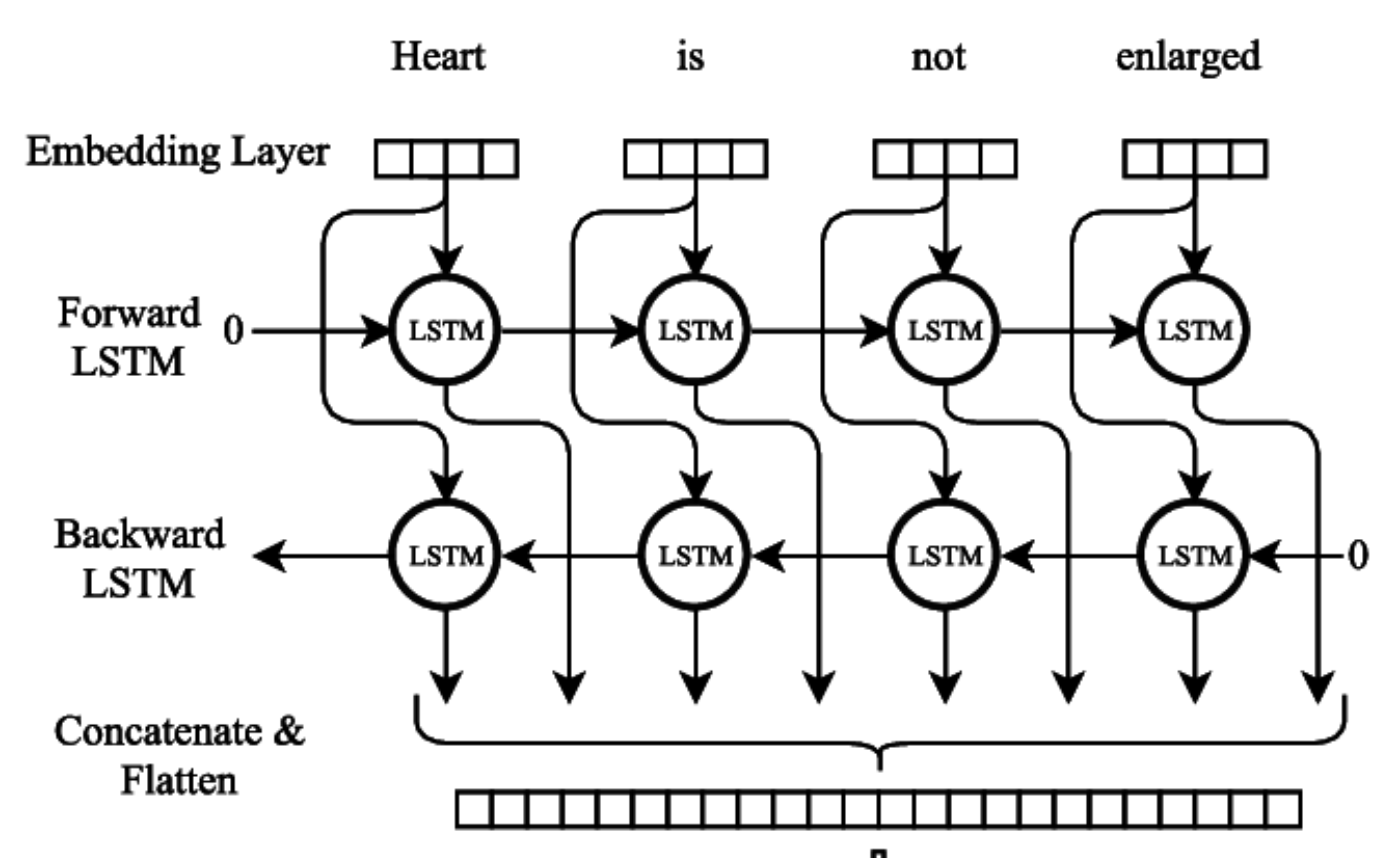

## Задание 7

Заполните метод `forward` класса `ModernTextClassifier`.

Запустите обучение модели.

In [ ]:
class ModernTextClassifier(nn.Module):
    def __init__(
        self,
        num_embeddings=25002,
        embedding_size=300,
        hidden_size=200,
        num_classes=2,
        num_layers=1,
        pad_token=1,
    ):
        super(ModernTextClassifier, self).__init__()
        self.embedding = nn.Embedding(
            num_embeddings, embedding_size, padding_idx=pad_token
        )
        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            batch_first=True,
            num_layers=num_layers,
            bidirectional=True,
        )
        self.linear = nn.Linear(hidden_size * num_layers, 1)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # ваш код здесь


device = "cuda:0"
pad_token = text_field.vocab.stoi["<pad>"]
model = ModernTextClassifier(
    hidden_size=512, embedding_size=100, num_layers=2, pad_token=pad_token
)
model.embedding.weight.data = text_field.vocab.vectors

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss()

for i in range(10):
    train_epoch(
        model, train_dataloader, criterion=criterion, optimizer=optimizer, device=device
    )

model(torch.tensor([[1, 2, 3, 4], [1, 2, 3, 4]]))